# Sleep Wearable Imputation

Mask known values → impute → score against the hidden truth using repeated k-fold cross-validation

Three scores per method:
- **nRMSE** - normalized prediction error (lower is better, `1.0` = no better than guessing the mean)
- **nbias** - whether it guesses too high or too low overall (`0` = neither)
- **sd_ratio** - percentage of variation (imputed data / original data), does the filled data still varies like real data (`1.0` = yes)

1. Setup
2. Load and gap structure
3. Masking
4. Imputation methods
5. Evaluation - physiological columns
6. Evaluation - behavioral columns
7. Export a filled dataset


## 1. Setup

In [32]:
import warnings
import contextlib
import hashlib
import importlib
import inspect
import io
import json
import logging
import threading
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import Normalize, TwoSlopeNorm
import seaborn as sns
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tools.sm_exceptions import ConvergenceWarning
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_absolute_error
from sklearn.impute import KNNImputer

for _cat in (ConvergenceWarning, RuntimeWarning, FutureWarning):
    warnings.filterwarnings("ignore", category=_cat)

# Paths
OURA_PATH = "../data/oura_sleep.csv"
SCORES_PATH = "../data/selfreport_nback_data.csv"

# Target columns
PHYSIO_COLS = [
    "average_breath",
    "average_heart_rate",
    "average_hrv",
    "deep_sleep_duration",
    "light_sleep_duration",
    "rem_sleep_duration",
]
BEHAV_COLS = ["selfassessment_value", "nback_score"]

# Evaluation parameters
SEED = 42
N_FOLDS = 5 # each fold hides 1/5 of the maskable pool 
N_REPEATS = 1 # different fold shuffles

# Labels
METHOD_LABELS = {
    "user_mean": "Personal Average",
    "ffill_bfill": "Forward/Backward Fill",
    "time_interp": "Linear Interpolation",
    "multivar_interp": "Multivariate Interpolation",
    "kalman": "Kalman Smoothing",
    "calendar": "Calendar Effect",
    "matrix_completion": "Matrix Completion",
    "matrix_completion_joint": "Matrix Completion (Joint)",
    "knn": "KNN",
    "saits": "SAITS",
    "tabpfn": "TabPFN",
    "timesfm": "TimesFM",
}
COLUMN_LABELS = {
    "selfassessment_value": "Subjective Sleep Rating",
    "nback_score": "N-back Score",
}
# row order for tables and heatmaps; filtered in 5.3 to whatever actually ran??????????????????????
METHOD_ORDER = ["user_mean", "ffill_bfill", "time_interp", "multivar_interp",
                "kalman", "calendar", "matrix_completion", "matrix_completion_joint",
                "saits", "tabpfn"]
SCORE_METHOD_ORDER = ["user_mean", "ffill_bfill", "time_interp", "kalman",
                      "calendar", "knn", "saits", "tabpfn"]

# ?????????????
class QuietBuffer(io.StringIO):
    """StringIO that reports an encoding - some libraries check it before printing."""
    encoding = "utf-8"


def probe_import(module, attr=None):
    """Is the package installed? Says nothing about whether its weights download."""
    try:
        with contextlib.redirect_stdout(QuietBuffer()): # pypots prints a banner
            m = importlib.import_module(module)
            if attr:
                getattr(m, attr)
        return True, ""
    except Exception as e:
        return False, f"{type(e).__name__}: {str(e).splitlines()[0][:90]}"


# ????????????????
_PYPOTS_LOGGER = logging.getLogger("PyPOTS running log")


def run_quietly(fn):
    """Run fn with pypots' banner (stdout) and warnings (its own logger) silenced."""
    was_disabled = _PYPOTS_LOGGER.disabled
    _PYPOTS_LOGGER.disabled = True
    try:
        with contextlib.redirect_stdout(QuietBuffer()):
            return fn()
    finally:
        _PYPOTS_LOGGER.disabled = was_disabled


# device=None lets pypots use the GPU if there is one, else CPU
SAITS_KW = dict(n_layers=2, d_model=64, n_heads=4, d_k=16, d_v=16, d_ffn=128,
                dropout=0.1, batch_size=32, epochs=20, patience=5,
                device=None, verbose=False)
SAITS_WINDOW, SAITS_STRIDE = 32, 4 # window length in nights and spacing

TABPFN_KW = dict(device="auto", ignore_pretraining_limits=True) # auto -> GPU if present
TIMESFM_KW = dict(repo_id="google/timesfm-2.5-200m-pytorch",
                  max_context=512, max_horizon=64, per_core_batch_size=32)

MODEL_CONFIG = {
    "saits": {**SAITS_KW, "window": SAITS_WINDOW, "stride": SAITS_STRIDE},
    "tabpfn": TABPFN_KW,
    "timesfm": TIMESFM_KW,
}

CAPABILITY_TIMEOUT = 100 # seconds before giving up on a weight download

CACHE_DIR = Path("../results_cache")
CACHE_DIR.mkdir(exist_ok=True, parents=True)
FIGURE_DIR = Path("../figures")
FIGURE_DIR.mkdir(exist_ok=True, parents=True)


## 2. Load and gap structure

### 2.1 Canonical nights

One row per participant per night. Keep real sleep sessions only (`sleep` and `long_sleep`), and where a night has multiple, keep the longest. Then give every participant a continuous daily calendar, nights that were not recorded at all become existing empty rows in the dataset.

In [33]:
def load_canonical_nights(path=OURA_PATH):
    """One row per (id, day): real sleep sessions only, longest kept per night."""
    cols = ["id", "day", "type", "period", "total_sleep_duration"] + PHYSIO_COLS
    df = pd.read_csv(path, usecols=cols)
    df["day"] = pd.to_datetime(df["day"])
    night = df[df["type"].isin(["long_sleep", "sleep"])].copy()
    night = night.sort_values(
        ["id", "day", "total_sleep_duration"], ascending=[True, True, False]
    )
    night = night.drop_duplicates(["id", "day"], keep="first")
    return night[["id", "day"] + PHYSIO_COLS].reset_index(drop=True)


def build_full_calendar(night):
    """Give each participant a day-by-day calendar with no dates skipped."""
    pieces = []
    for uid, g in night.groupby("id"):
        g = g.set_index("day").sort_index()
        g = g.reindex(pd.date_range(g.index.min(), g.index.max(), freq="D"))
        g["id"] = uid
        g.index.name = "day"
        pieces.append(g.reset_index())
    full = pd.concat(pieces, ignore_index=True)
    return full[["id", "day"] + PHYSIO_COLS]

night = load_canonical_nights()
full = build_full_calendar(night)

n_structural = full[PHYSIO_COLS].isna().all(axis=1).sum()
pd.DataFrame({
    "metric": [
        "users",
        "canonical nights (long_sleep + sleep, deduped)",
        "user-nights after reindexing to full calendars",
        "fully-unrecorded nights (structural gaps)",
        "recorded nights with a real value present",
    ],
    "value": [
        full["id"].nunique(),
        len(night),
        len(full),
        n_structural,
        len(full) - n_structural,
    ],
})

,metric,value
0,users,29
1,"canonical nights (long_sleep + sleep, deduped)",1679
2,user-nights after reindexing to full calendars,1877
3,fully-unrecorded nights (structural gaps),207
4,recorded nights with a real value present,1670


### 2.2 Gap lengths

How long are the gaps present in the dataset ? This helps decide how should the data be masked for evaluation.


In [34]:
def gap_lengths(df, is_missing):
    runs = []
    tmp = df.assign(_missing=is_missing).sort_values(["id", "day"])
    for _, g in tmp.groupby("id"):
        run = 0
        for v in g["_missing"].to_numpy():
            if v:
                run += 1
            elif run:
                runs.append(run)
                run = 0
        if run:
            runs.append(run)

    tab = pd.Series(runs).value_counts().sort_index().rename("Number of gaps").to_frame()
    tab["Total number of nights"] = tab.index * tab["Number of gaps"]
    tab.index.name = "Length of gap (nights)"
    return tab

gap_lengths(full, full[PHYSIO_COLS].isna().all(axis=1))

,Number of gaps,Total number of nights
Length of gap (nights),,
1,95,95
2,15,30
3,6,18
6,2,12
7,1,7
9,1,9
10,1,10
11,1,11
15,1,15


## 3. Masking

We build a pool of every night that can be hidden, then split it into `N_FOLDS` groups. Each fold hides one group and leaves the rest real, so every night in the pool gets tested exactly once. Repeating with different splits (`N_REPEATS`) helps get results we can trust even more.

In [35]:
def build_gap_pool(df, recorded, length_range, seed=SEED):
    rng = np.random.default_rng(seed)
    order = df.sort_values(["id", "day"]).index.to_numpy()
    rec_o = recorded.loc[order].to_numpy()
    id_o = df.loc[order, "id"].to_numpy()

    pool = []
    for uid in pd.unique(id_o):
        m = id_o == uid
        idx, rec = order[m], rec_o[m]
        n = len(idx)
        claimed = np.zeros(n, dtype=bool)
        pos = 0
        while pos < n:
            length = int(rng.integers(length_range[0], length_range[1] + 1))
            end = pos + length
            fits = end <= n and rec[pos:end].all() and not claimed[pos:end].any()
            before_ok = pos == 0 or (rec[pos - 1] and not claimed[pos - 1])
            after_ok = end >= n or (rec[end] and not claimed[end])
            if fits and before_ok and after_ok:
                pool.append(idx[pos:end].tolist())
                claimed[pos:end] = True
                pos = end
            else:
                pos += 1
    return pool


def make_folds(pool, n_folds, seed):
    pool = list(pool)
    np.random.default_rng(seed).shuffle(pool)
    return [pool[i::n_folds] for i in range(n_folds)]


def mask_indices(df, cols, indices):
    masked = df.copy()
    true_vals = pd.DataFrame(np.nan, index=df.index, columns=cols)
    true_vals.loc[indices, cols] = df.loc[indices, cols].values
    masked.loc[indices, cols] = np.nan
    return masked, true_vals, true_vals.notna()

recorded = full[PHYSIO_COLS].notna().all(axis=1)
single_pool = build_gap_pool(full, recorded, length_range=(1, 1))
block_pool = build_gap_pool(full, recorded, length_range=(2, 3))

## 4. Imputation methods

Every method takes `(df, cols)` and returns a filled `df`, so they are
interchangeable in the evaluation loop.


### 4.0 Shared safeguard

Whatever a method could not fill (a gap right at the start or end of a series) falls back to the participant's own mean, then to the overall mean.


In [36]:
def _fill_remaining(out, cols, ref):
    out[cols] = out.groupby("id")[cols].transform(lambda s: s.fillna(s.mean()))
    out[cols] = out[cols].fillna(ref[cols].mean())
    return out

### 4.1 Personal average

The baseline, the participant's own mean for that column.


In [37]:
def impute_user_mean(df, cols=PHYSIO_COLS):
    return _fill_remaining(df.copy(), cols, df)

### 4.2 Forward / Backward fill

Copies the nearest known value across the gap, up to `limit` nights.


In [38]:
def impute_ffill_bfill(df, cols=PHYSIO_COLS, limit=6):
    out = df.copy()
    for uid, g in out.groupby("id"):
        g_sorted = g.sort_values("day")
        out.loc[g_sorted.index, cols] = (
            g_sorted[cols].ffill(limit=limit).bfill(limit=limit).values
        )
    return _fill_remaining(out, cols, df)

### 4.3 Linear interpolation

Straight line between the values on either side of the gap.

In [39]:
def impute_time_interp(df, cols=PHYSIO_COLS, max_gap=6):
    out = df.copy()
    for uid, g in out.groupby("id"):
        g_sorted = g.sort_values("day")
        ts = g_sorted.set_index("day")[cols]
        interp = ts.interpolate(method="time", limit=max_gap, limit_area="inside")
        out.loc[g_sorted.index, cols] = interp.fillna(ts.mean()).values
    return _fill_remaining(out, cols, df)

### 4.4 Multivariate interpolation

Predicts each column from the before/after values of **all** 6 physiological columns we are looking at.

The regressor is swappable, Ridge here, TabPFN later reuses this exact same code with a different model.

In [40]:
def _bracket_features(out, cols, max_gap):
    X = {}
    for c in cols:
        before, after = [], []
        for _, g in out.groupby("id"):
            s = g.sort_values("day")[c]
            before.append(s.shift(1).ffill(limit=max_gap))
            after.append(s.shift(-1).bfill(limit=max_gap))
        X[f"{c}_before"] = pd.concat(before).reindex(out.index)
        X[f"{c}_after"] = pd.concat(after).reindex(out.index)
    return pd.DataFrame(X)


def impute_bracket_regression(df, cols=PHYSIO_COLS, max_gap=5, model_factory=None):
    model_factory = model_factory or (lambda: Ridge(alpha=1.0))
    out = df.copy()
    uid = out["id"]

    X = _bracket_features(out, cols, max_gap)
    x_mean, x_std = X.groupby(uid).transform("mean"), X.groupby(uid).transform("std")
    y_mean = out.groupby(uid)[cols].transform("mean")
    y_std = out.groupby(uid)[cols].transform("std")
    Xz = (X - x_mean) / x_std.replace(0, np.nan)
    Yz = (out[cols] - y_mean) / y_std.replace(0, np.nan)

    has_brackets = Xz.notna().all(axis=1)
    for c in cols:
        train = has_brackets & Yz[c].notna()
        missing = has_brackets & out[c].isna()
        if train.sum() < 10 or missing.sum() == 0:
            continue
        model = model_factory().fit(Xz.loc[train], Yz.loc[train, c])
        z_hat = model.predict(Xz.loc[missing])
        out.loc[missing, c] = z_hat * y_std.loc[missing, c] + y_mean.loc[missing, c]

    return _fill_remaining(out, cols, df)


def impute_multivar_interp(df, cols=PHYSIO_COLS, max_gap=5, alpha=1.0):
    return impute_bracket_regression(df, cols, max_gap, lambda: Ridge(alpha=alpha))


### 4.5 Kalman smoothing

Fits a simple time-series model (AR(1)) per participant per column, and smooths
across the gap using the data on both sides. Participants with too little data, or
fits that blow up outside the observed range, are skipped and left to the safeguard.

In [41]:
def impute_kalman(df, cols=PHYSIO_COLS, min_obs=10, return_se=False):
    out = df.copy()
    se = pd.DataFrame(np.nan, index=df.index, columns=cols)

    for uid, g in out.groupby("id"):
        g_sorted = g.sort_values("day")
        idx = g_sorted.index
        for col in cols:
            y = g_sorted[col].astype(float).to_numpy()
            n_obs = np.isfinite(y).sum()
            sd = np.nanstd(y) if n_obs else np.nan
            if n_obs < min_obs or not np.isfinite(sd) or sd == 0:
                continue

            try:
                res = SARIMAX(
                    y,
                    order=(1, 0, 0),
                    trend="c",
                    enforce_stationarity=True,
                    initialization="stationary",
                ).fit(disp=False)
                sm = np.asarray(res.smoother_results.smoothed_forecasts).ravel()
                sm_var = np.asarray(res.smoother_results.smoothed_forecasts_error_cov).ravel()
            except Exception:
                continue

            if not np.all(np.isfinite(sm)):
                continue

            lo, hi = np.nanmin(y), np.nanmax(y)
            span = hi - lo
            if np.nanmin(sm) < lo - 3 * span or np.nanmax(sm) > hi + 3 * span:
                continue

            out.loc[idx, col] = np.where(np.isnan(y), sm, y)
            se.loc[idx, col] = np.sqrt(np.clip(sm_var, 0, None))

    out = _fill_remaining(out, cols, df)
    return out

### 4.6 Calendar effect

Personal average, plus whatever the whole group did on that specific date. The group
effect is shrunk toward zero when few participants contributed that date (`k_smooth`).


In [42]:
def impute_calendar(df, cols=PHYSIO_COLS, k_smooth=20):
    out = df.copy()
    user_mean = out.groupby("id")[cols].transform("mean")
    user_std = out.groupby("id")[cols].transform("std")
    global_mean, global_std = out[cols].mean(), out[cols].std()
    mean_used = user_mean.fillna(global_mean)
    std_used = user_std.replace(0, np.nan).fillna(global_std)

    z = (out[cols] - mean_used) / std_used

    predicted = mean_used.copy()
    for col in cols:
        obs = z[col].notna()
        grp = z.loc[obs, col].groupby(out.loc[obs, "day"])
        raw, n = grp.mean(), grp.count()
        date_effect_z = (raw * (n / (n + k_smooth))).to_dict()
        predicted[col] = (
            mean_used[col] + out["day"].map(date_effect_z).fillna(0.0) * std_used[col]
        )

    out[cols] = out[cols].where(out[cols].notna(), predicted)
    return _fill_remaining(out, cols, df)

### 4.7 SAITS (deep learning, trained from scratch)

A transformer, via `pypots`. Not pretrained, it learns from this dataset alone.

In [43]:
def _to_windows(df, cols, n_steps, stride):
    windows, coords = [], []
    for uid, g in df.groupby("id"):
        g = g.sort_values("day")
        idx, arr, n = g.index.to_numpy(), g[cols].to_numpy(dtype=float), len(g)
        starts = list(range(0, max(n - n_steps, 0) + 1, stride))
        if starts[-1] + n_steps < n:
            starts.append(max(n - n_steps, 0))
        for s in starts:
            e = min(s + n_steps, n)
            w, c = arr[s:e], idx[s:e]
            if len(w) < n_steps:                      # pad the tail
                w = np.vstack([w, np.full((n_steps - len(w), len(cols)), np.nan)])
                c = np.concatenate([c, np.full(n_steps - len(c), -1)])
            windows.append(w)
            coords.append(c)
    return np.asarray(windows), np.asarray(coords)

def impute_saits(df, cols=PHYSIO_COLS, n_steps=SAITS_WINDOW, stride=SAITS_STRIDE,
                 seed=SEED, **kw):
    import torch

    out = df.copy()
    torch.manual_seed(seed)
    np.random.seed(seed)

    mu = out.groupby("id")[cols].transform("mean")
    sd = out.groupby("id")[cols].transform("std").replace(0, np.nan)
    z = out.copy()
    z[cols] = (out[cols] - mu) / sd

    X, C = _to_windows(z, cols, n_steps, stride)

    def _fit_predict():
        from pypots.imputation import SAITS
        model = SAITS(n_steps=X.shape[1], n_features=X.shape[2], **{**SAITS_KW, **kw})
        model.fit({"X": X})
        return model.predict({"X": X})["imputation"]

    P = run_quietly(_fit_predict)

    acc = pd.DataFrame(0.0, index=out.index, columns=cols)
    cnt = pd.DataFrame(0.0, index=out.index, columns=cols)
    for w, c in zip(P, C):
        v = c >= 0
        acc.loc[c[v], cols] += w[v]
        cnt.loc[c[v], cols] += 1
    pred = (acc / cnt.replace(0, np.nan)) * sd + mu

    out[cols] = out[cols].where(out[cols].notna(), pred[cols])
    return _fill_remaining(out, cols, df)

### 4.8 TabPFN (pretrained)

A pretrained tabular model. Fed the same before/after features as 4.4, so it acts
like a nonlinear Kalman. The same code path as `multivar_interp`, with
TabPFN in place of Ridge.

Needs weights downloaded from Hugging Face - see 4.10.

In [44]:
def impute_tabpfn(df, cols=PHYSIO_COLS, max_gap=5):
    from tabpfn import TabPFNRegressor
    return impute_bracket_regression(
        df, cols, max_gap, lambda: TabPFNRegressor(**TABPFN_KW))


### 4.9 TimesFM (pretrained, time-series)

Disabled by default, commented out of the method list in 5.3. On CPU and personal GPU it did not finish running in any practical time.
The code is complete and correct if you have a GPU.

TimesFM only looks backwards, so it cannot fill a gap directly. The wrapper runs it
forwards from the left edge of the gap, then again on the reversed series from the
right edge, and blends the two by distance. The model is loaded once and reused.

Needs weights from Hugging Face - see 4.10.


In [45]:
def _bidirectional_fill(series, forecast_fn, context_len=64):
    y = np.asarray(series, dtype=float)
    n = len(y)
    filled = y.copy()

    gaps, start = [], None
    for i, v in enumerate(np.isnan(y)):
        if v and start is None:
            start = i
        elif not v and start is not None:
            gaps.append((start, i))
            start = None
    if start is not None:
        gaps.append((start, n))

    base = pd.Series(y).interpolate(limit_direction="both").to_numpy()
    if np.isnan(base).all():
        return filled

    for a, b in gaps:
        h = b - a
        fwd = bwd = None
        if a > 0:
            ctx = base[max(0, a - context_len):a]
            fwd = np.asarray(forecast_fn(ctx, h))[:h] if len(ctx) else None
        if b < n:
            ctx = base[b:min(n, b + context_len)][::-1]
            bwd = np.asarray(forecast_fn(ctx, h))[:h][::-1] if len(ctx) else None

        if fwd is None and bwd is None:
            continue
        if fwd is None:
            filled[a:b] = bwd
        elif bwd is None:
            filled[a:b] = fwd
        else:
            w = (np.arange(h) + 1) / (h + 1)
            filled[a:b] = (1 - w) * fwd + w * bwd
    return filled

def make_forecast_imputer(forecast_fn, context_len=64):
    def _impute(df, cols=PHYSIO_COLS):
        out = df.copy()
        for uid, g in out.groupby("id"):
            gs = g.sort_values("day")
            for c in cols:
                out.loc[gs.index, c] = _bidirectional_fill(
                    gs[c].to_numpy(float), forecast_fn, context_len)
        return _fill_remaining(out, cols, df)
    return _impute

_TIMESFM = None

def get_timesfm(retries=3, backoff=5):
    global _TIMESFM
    if _TIMESFM is not None:
        return _TIMESFM

    import time
    import timesfm

    last_err = None
    for attempt in range(1, retries + 1):
        try:
            model = timesfm.TimesFM_2p5_200M_torch.from_pretrained(TIMESFM_KW["repo_id"])
            model.compile(timesfm.ForecastConfig(
                max_context=TIMESFM_KW["max_context"],
                max_horizon=TIMESFM_KW["max_horizon"],
                normalize_inputs=True,
                per_core_batch_size=TIMESFM_KW["per_core_batch_size"],
            ))
            _TIMESFM = model
            return _TIMESFM
        except Exception as e:
            last_err = e
            if attempt < retries:
                time.sleep(backoff * attempt)
    raise last_err


def impute_timesfm(df, cols=PHYSIO_COLS):
    model = get_timesfm()

    def _forecast(context, horizon):
        point, _ = model.forecast(horizon=horizon,
                                  inputs=[np.asarray(context, dtype=float)])
        return np.asarray(point[0])[:horizon]

    return make_forecast_imputer(_forecast)(df, cols=cols)

### 4.10 Which backends can actually run

TabPFN and TimesFM are pretrained, so being installed is not enough, the weights have to actually be downloaded.

Each one is properly tested (a tiny real fit / model load) with a timeout, so a stuck download cannot freeze the kernel. The answer is remembered in `results_cache/_capabilities.json`, and packages that are not installed are skipped instantly.

In [46]:
CAPABILITY_PATH = CACHE_DIR / "_capabilities.json"

def _run_with_timeout(fn, seconds):
    """Run fn in a daemon thread; give up after `seconds` rather than blocking."""
    out = {}

    def target():
        try:
            fn()
            out["ok"] = True
        except Exception as e:
            out["ok"] = False
            out["err"] = f"{type(e).__name__}: {str(e).splitlines()[0][:90]}"

    t = threading.Thread(target=target, daemon=True)
    t.start()
    t.join(seconds)
    if t.is_alive():
        return False, f"timed out after {seconds}s - download still running?"
    return out.get("ok", False), out.get("err", "")


def capability(name, probe, refresh=False, timeout=CAPABILITY_TIMEOUT):
    """Can this backend really run? Probed once, then remembered on disk."""
    store = json.loads(CAPABILITY_PATH.read_text()) if CAPABILITY_PATH.exists() else {}
    if name in store and not refresh:
        return store[name]["ok"], store[name]["note"]

    ok, note = _run_with_timeout(probe, timeout)
    store[name] = {"ok": ok, "note": note or "ready",
                   "checked": pd.Timestamp.now().isoformat(timespec="seconds")}
    CAPABILITY_PATH.write_text(json.dumps(store, indent=2))
    return ok, store[name]["note"]


def _probe_tabpfn():
    from tabpfn import TabPFNRegressor
    TabPFNRegressor(**TABPFN_KW).fit(np.random.randn(30, 3), np.random.randn(30))

_tabpfn_installed, _tabpfn_err = probe_import("tabpfn", "TabPFNRegressor")
TABPFN_OK, TABPFN_NOTE = (capability("tabpfn", _probe_tabpfn)
                          if _tabpfn_installed else (False, _tabpfn_err))

_timesfm_installed, _timesfm_err = probe_import("timesfm")
TIMESFM_OK, TIMESFM_NOTE = (capability("timesfm", get_timesfm)
                            if _timesfm_installed else (False, _timesfm_err))

BACKENDS = pd.DataFrame([
    {"method": "tabpfn", "detail": TABPFN_NOTE},
    {"method": "timesfm", "detail": TIMESFM_NOTE},
])
BACKENDS

,method,detail
0,tabpfn,ready
1,timesfm,ready


### 4.11 Matrix completion — cross-participant structure

**Disabled by default** — commented out of the method list in 5.3, kept here as a
documented negative result.

Every other method fills a gap from the same participant's own history, or from other
columns on the same night. This one asks instead whether *other participants* look
like this one: reshape into a participants × nights matrix and fill from the shared
patterns found by low-rank SVD.

Nights are lined up by each participant's own night number rather than calendar date,
so this tests a shared *shape over time* (4.6 already tests shared calendar dates).

Tested at rank 1/2/3/5: results get steadily worse as rank goes up, which is what
overfitting looks like with only 29 participants. Even at rank 1 it does not beat the
personal average.


In [47]:
def _iterative_svd_fill(M, rank=1, max_iter=50, tol=1e-4):
    """Dependency-free matrix completion: fill missing cells with the current
    low-rank reconstruction, recompute the SVD, repeat until stable."""
    mask = ~np.isnan(M)
    if not mask.any():
        return M
    M_filled = np.where(mask, M, 0.0)   # already z-scored, so 0 is a sensible cold start
    for _ in range(max_iter):
        U, S, Vt = np.linalg.svd(M_filled, full_matrices=False)
        k = min(rank, len(S))
        recon = (U[:, :k] * S[:k]) @ Vt[:k, :]
        new_filled = np.where(mask, M, recon)
        delta = np.linalg.norm(new_filled - M_filled) / (np.linalg.norm(M_filled) + 1e-9)
        M_filled = new_filled
        if delta < tol:
            break
    return M_filled


def _relative_day(df):
    """Each participant's own night number, 0..n_i-1. Calendars are already
    gap-free per participant (2.1), so this is just position-in-series."""
    return df.sort_values(["id", "day"]).groupby("id").cumcount().reindex(df.index)


def impute_matrix_completion(df, cols=PHYSIO_COLS, rank=1):
    """One participants x nights matrix per column."""
    out = df.copy()
    mean_ = out.groupby("id")[cols].transform("mean")
    std_ = out.groupby("id")[cols].transform("std").replace(0, np.nan)
    z = (out[cols] - mean_) / std_

    rel_day = _relative_day(out)
    id_pos = out["id"].map({u: i for i, u in enumerate(sorted(out["id"].unique()))})
    n_p, n_d = id_pos.nunique(), int(rel_day.max()) + 1
    rows, day_pos = id_pos.to_numpy(), rel_day.to_numpy()

    for c in cols:
        M = np.full((n_p, n_d), np.nan)
        M[rows, day_pos] = z[c].to_numpy()
        filled = _iterative_svd_fill(M, rank=rank)
        pred = filled[rows, day_pos] * std_[c].to_numpy() + mean_[c].to_numpy()
        missing = out[c].isna().to_numpy()
        out.loc[missing, c] = pred[missing]

    return _fill_remaining(out, cols, df)


def impute_matrix_completion_joint(df, cols=PHYSIO_COLS, rank=1):
    """One participants x (night, column) matrix, sharing structure across
    participants AND columns at once."""
    out = df.copy()
    mean_ = out.groupby("id")[cols].transform("mean")
    std_ = out.groupby("id")[cols].transform("std").replace(0, np.nan)
    z = (out[cols] - mean_) / std_

    rel_day = _relative_day(out)
    id_pos = out["id"].map({u: i for i, u in enumerate(sorted(out["id"].unique()))})
    n_p, n_d, n_c = id_pos.nunique(), int(rel_day.max()) + 1, len(cols)
    rows, day_pos = id_pos.to_numpy(), rel_day.to_numpy()

    M = np.full((n_p, n_d * n_c), np.nan)
    for j, c in enumerate(cols):
        M[rows, day_pos * n_c + j] = z[c].to_numpy()

    filled = _iterative_svd_fill(M, rank=rank)

    for j, c in enumerate(cols):
        pred = filled[rows, day_pos * n_c + j] * std_[c].to_numpy() + mean_[c].to_numpy()
        missing = out[c].isna().to_numpy()
        out.loc[missing, c] = pred[missing]

    return _fill_remaining(out, cols, df)


## 5. Evaluation of the physiological columns

In [48]:
def evaluate(true_vals, imputed_df, mask_indicator, cols=PHYSIO_COLS, ref_std=None):
    """Score the guesses against the hidden truth."""
    rows = []
    for col in cols:
        idx = mask_indicator.index[mask_indicator[col]]
        y_true = true_vals.loc[idx, col].astype(float)
        y_pred = imputed_df.loc[idx, col].astype(float)
        valid = y_true.notna() & y_pred.notna()
        y_true, y_pred = y_true[valid], y_pred[valid]
        if len(y_true) == 0:
            continue

        rmse = float(np.sqrt(np.mean((y_true - y_pred) ** 2)))
        bias = float((y_pred - y_true).mean())
        sd = float(ref_std[col]) if ref_std is not None else float(y_true.std())

        rows.append({
            "column": col,
            "n_eval": int(valid.sum()),
            "rmse": rmse,
            "mae": mean_absolute_error(y_true, y_pred),
            "bias": bias,
            "nrmse": rmse / sd if sd > 0 else np.nan,
            "nbias": bias / sd if sd > 0 else np.nan,
            "sd_ratio": float(y_pred.std() / y_true.std()) if y_true.std() > 0 else np.nan,
        })
    return pd.DataFrame(rows)

### 5.1 Cross-validation runner

In [49]:
def cross_validate(df, pool, cols, methods, n_folds=N_FOLDS, n_repeats=N_REPEATS):
    """Run every method on every fold of every repeat."""
    ref_std = df[cols].std()
    rows = []
    for rep in range(n_repeats):
        for k, fold in enumerate(make_folds(pool, n_folds, seed=SEED + rep)):
            idx = [i for block in fold for i in block]
            masked, true_vals, mask_ind = mask_indices(df, cols, idx)
            for name, fn in methods.items():
                res = evaluate(true_vals, fn(masked, cols=cols), mask_ind,
                               cols=cols, ref_std=ref_std)
                res["method"], res["repeat"], res["fold"] = name, rep, k
                rows.append(res)
    return pd.concat(rows, ignore_index=True)


### 5.2 Per-method results cache

Each method's results are saved to `results_cache/<tag>__<method>.csv` and reloaded
next run, so changing one method does not recompute all of them.

Every saved file carries a fingerprint of the things that could change its numbers:
the method's own code, the shared scoring code, the CV settings, the data pools, and a
checksum of the data. If any of those change, that file is ignored and that method
alone recomputes.


In [50]:
def _src(fn):
    try:
        return inspect.getsource(fn)
    except (OSError, TypeError):
        return repr(fn)


def fingerprint(name, fn, df, cols, pools):
    parts = [
        _src(fn) if fn is not None else name,
        _src(evaluate), _src(cross_validate), _src(_fill_remaining),
        f"{N_FOLDS}|{N_REPEATS}|{SEED}",
        str(sorted(map(str, cols))),
        str(pools),
        str(int(pd.util.hash_pandas_object(df[cols].fillna(0)).sum())),
    ]
    cfg = MODEL_CONFIG.get(name)
    if cfg:
        parts.append(str(sorted((k, str(v)) for k, v in cfg.items())))
    return hashlib.sha1("|".join(parts).encode()).hexdigest()[:12]


def cached_cv(df, pool_specs, cols, methods, tag, force=()):
    frames = []
    for name, fn in methods.items():
        path = CACHE_DIR / f"{tag}__{name}.csv"
        fp = fingerprint(name, fn, df, cols, pool_specs)

        if path.exists() and name not in force:
            cached = pd.read_csv(path)
            if str(cached["fingerprint"].iloc[0]) == fp:
                frames.append(cached)
                print(f"  {name:<16} cached")
                continue
            print(f"  {name:<16} STALE - recomputing")
        else:
            print(f"  {name:<16} computing")

        parts = []
        for scenario, pool in pool_specs.items():
            r = cross_validate(df, pool, cols, {name: fn})
            r["masking"] = scenario
            parts.append(r)
        res = pd.concat(parts, ignore_index=True)
        res["fingerprint"] = fp
        res["computed_at"] = pd.Timestamp.now().isoformat(timespec="seconds")
        res.to_csv(path, index=False)
        frames.append(res)

    return pd.concat(frames, ignore_index=True)

### 5.3 Run on both masking scenarios

Matrix completion and TimesFM are commented out — see 4.11 and 4.9 for why.


In [51]:
methods = {
    "user_mean": impute_user_mean,
    "ffill_bfill": impute_ffill_bfill,
    "time_interp": impute_time_interp,
    "multivar_interp": impute_multivar_interp,
    "kalman": impute_kalman,
    "calendar": impute_calendar,
    "saits": impute_saits,
    "matrix_completion": impute_matrix_completion,
    "matrix_completion_joint": impute_matrix_completion_joint,
}

for _name, _ok, _fn, _note in [
    ("tabpfn", TABPFN_OK, impute_tabpfn, TABPFN_NOTE),
    #("timesfm", TIMESFM_OK, impute_timesfm, TIMESFM_NOTE),
]:
    if _ok:
        methods[_name] = _fn
    else:
        print(f"  {_name:<16} unavailable - {_note}")

METHOD_ORDER = [m for m in METHOD_ORDER if m in methods]

physio_pools = {
    "Single night masking": single_pool,
    "Night blocks masking (2-3 day gaps)": block_pool,
}
results = cached_cv(full, physio_pools, PHYSIO_COLS, methods, tag="physio")

print(f"\n{len(results)} rows | {N_FOLDS} folds x {N_REPEATS} repeats "
      f"| {len(methods)} methods | pools: {len(single_pool)} nights, {len(block_pool)} blocks")

  user_mean        STALE - recomputing
  ffill_bfill      STALE - recomputing
  time_interp      STALE - recomputing
  multivar_interp  STALE - recomputing
  kalman           STALE - recomputing
  calendar         STALE - recomputing
  saits            STALE - recomputing
  matrix_completion STALE - recomputing
  matrix_completion_joint STALE - recomputing
  tabpfn           STALE - recomputing

600 rows | 5 folds x 1 repeats | 10 methods | pools: 756 nights, 403 blocks


### 5.4 Three metrics

- **nRMSE** - normalized prediction error (lower is better, `1.0` = no better than guessing the mean)
- **nbias** - whether it guesses too high or too low overall (`0` = neither)
- **sd_ratio** - percentage of variation (imputed data / original data), does the filled data still varies like real data (`1.0` = yes)

In [52]:
def mean_pm(df, value, index="column", columns="method", order=None):
    """Pivot to 'mean' strings over all folds/repeats."""
    mean = df.pivot_table(index=index, columns=columns, values=value)
    if order:
        mean = mean[order]
    return mean.round(3).astype(str)


for scheme in results["masking"].unique():
    sub = results[results["masking"] == scheme]
    for metric in ["nrmse", "nbias", "sd_ratio"]:
        print(f"{scheme} - {metric}")
        display(mean_pm(sub, metric, order=METHOD_ORDER))

Single night masking - nrmse


method,user_mean,ffill_bfill,time_interp,multivar_interp,kalman,calendar,matrix_completion,matrix_completion_joint,saits,tabpfn
column,,,,,,,,,,
average_breath,0.487,0.494,0.413,0.406,0.378,0.49,0.513,0.495,0.476,0.401
average_heart_rate,0.616,0.762,0.652,0.581,0.534,0.62,0.659,0.666,0.641,0.577
average_hrv,0.505,0.665,0.568,0.502,0.444,0.511,0.528,0.522,0.503,0.494
deep_sleep_duration,0.781,1.107,0.96,0.773,0.783,0.78,0.852,0.819,0.807,0.768
light_sleep_duration,0.881,1.241,1.076,0.857,0.883,0.882,0.919,0.898,0.891,0.858
rem_sleep_duration,0.789,1.15,0.996,0.781,0.79,0.793,0.831,0.823,0.808,0.779


Single night masking - nbias


method,user_mean,ffill_bfill,time_interp,multivar_interp,kalman,calendar,matrix_completion,matrix_completion_joint,saits,tabpfn
column,,,,,,,,,,
average_breath,0.011,-0.003,0.011,0.004,0.001,0.013,0.015,0.012,-0.108,0.0
average_heart_rate,0.012,0.018,0.018,0.01,0.016,0.01,0.045,0.02,-0.191,-0.002
average_hrv,-0.002,-0.015,-0.008,-0.001,-0.003,-0.003,0.0,-0.009,0.027,-0.001
deep_sleep_duration,-0.004,-0.007,-0.024,-0.002,0.005,-0.008,-0.017,-0.003,0.196,0.003
light_sleep_duration,-0.0,-0.023,-0.019,0.011,-0.0,-0.005,-0.012,0.001,0.108,0.008
rem_sleep_duration,0.009,0.014,0.004,0.014,0.012,0.006,0.026,0.014,0.144,0.016


Single night masking - sd_ratio


...

method,user_mean,ffill_bfill,time_interp,multivar_interp,kalman,calendar,matrix_completion,matrix_completion_joint,saits,tabpfn
column,,,,,,,,,,
average_breath,0.478,0.521,0.446,0.41,0.382,0.48,0.504,0.497,0.465,0.4
average_heart_rate,0.635,0.783,0.685,0.617,0.59,0.633,0.665,0.67,0.668,0.616
average_hrv,0.528,0.649,0.568,0.52,0.5,0.532,0.554,0.549,0.527,0.519
deep_sleep_duration,0.763,1.077,0.946,0.77,0.761,0.766,0.848,0.801,0.797,0.766
light_sleep_duration,0.889,1.209,1.057,0.887,0.89,0.893,0.978,0.924,0.9,0.887
rem_sleep_duration,0.777,1.147,0.985,0.784,0.784,0.783,0.834,0.827,0.789,0.78


Night blocks masking (2-3 day gaps) - nbias


method,user_mean,ffill_bfill,time_interp,multivar_interp,kalman,calendar,matrix_completion,matrix_completion_joint,saits,tabpfn
column,,,,,,,,,,
average_breath,0.014,0.02,0.035,0.009,0.028,0.015,0.007,0.017,-0.093,0.005
average_heart_rate,-0.012,-0.024,-0.031,-0.028,-0.011,-0.014,-0.001,-0.004,-0.2,-0.037
average_hrv,0.012,0.02,0.024,0.021,0.005,0.016,0.006,0.011,0.026,0.019
deep_sleep_duration,0.023,0.029,0.018,0.032,0.018,0.027,0.016,0.016,0.226,0.036
light_sleep_duration,-0.001,0.003,-0.019,0.017,-0.005,0.002,-0.011,-0.006,0.115,0.012
rem_sleep_duration,-0.005,0.006,-0.03,0.005,-0.004,-0.004,0.0,-0.017,0.122,0.006


Night blocks masking (2-3 day gaps) - sd_ratio


method,user_mean,ffill_bfill,time_interp,multivar_interp,kalman,calendar,matrix_completion,matrix_completion_joint,saits,tabpfn
column,,,,,,,,,,
average_breath,0.892,1.051,0.996,0.914,0.954,0.894,0.918,0.906,0.902,0.914
average_heart_rate,0.791,0.995,0.921,0.824,0.839,0.792,0.822,0.81,0.783,0.827
average_hrv,0.865,1.016,0.955,0.885,0.875,0.87,0.896,0.879,0.874,0.881
deep_sleep_duration,0.651,1.049,0.912,0.663,0.683,0.66,0.733,0.695,0.667,0.658
light_sleep_duration,0.481,0.956,0.777,0.506,0.489,0.494,0.679,0.573,0.499,0.5
rem_sleep_duration,0.632,1.042,0.865,0.647,0.647,0.635,0.726,0.684,0.657,0.643


### 5.5 Heatmaps

All methods × all six physiological columns, averaged over both masking scenarios and
every fold.

nRMSE uses a plain light-to-dark scale (lighter = better). nbias and sd_ratio use a
two-colour scale centred on their ideal value (`0` and `1`), so white = ideal and
colour = drifting either way.


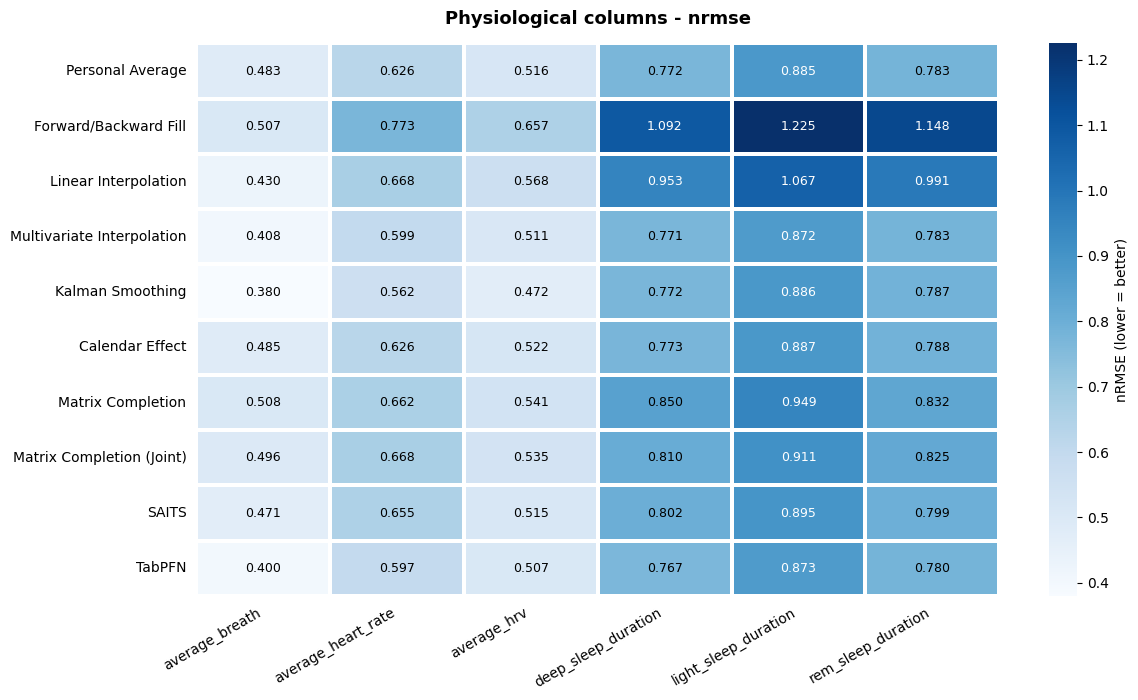

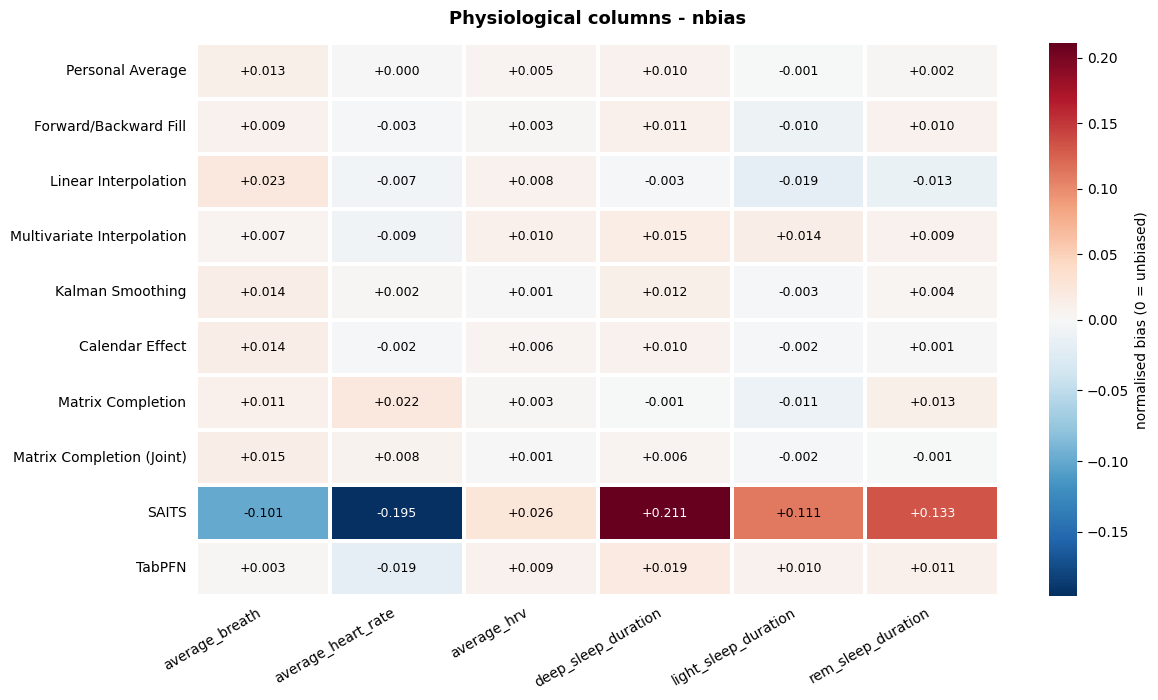

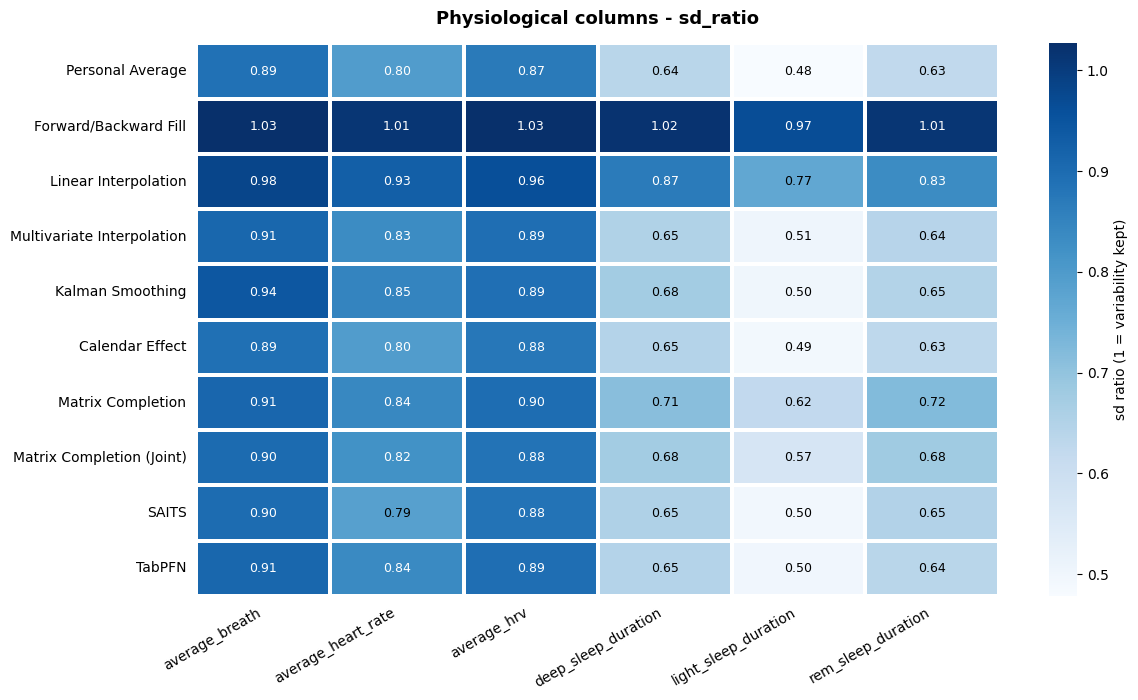

In [61]:
def plot_metric_heatmap(table, title, cmap="Blues", vmin=None, vmax=None,
                        center=None, fmt="{:.3f}", cbar_label=None, outfile=None):
    values = table.values.astype(float)
    vmin = np.nanmin(values) if vmin is None else vmin
    vmax = np.nanmax(values) if vmax is None else vmax
    if center is not None:
        vmin, vmax = min(vmin, center - 1e-9), max(vmax, center + 1e-9)
        norm = TwoSlopeNorm(vcenter=center, vmin=vmin, vmax=vmax)
    else:
        norm = Normalize(vmin=vmin, vmax=vmax)

    cm = plt.get_cmap(cmap)
    fig, ax = plt.subplots(figsize=(2.0 + 1.7 * table.shape[1], 0.55 * len(table) + 1.6))
    sns.heatmap(table, annot=False, cmap=cm, norm=norm, cbar=True,
                cbar_kws={"label": cbar_label or title},
                linewidths=1.5, linecolor="white", ax=ax)

    for i in range(table.shape[0]):
        for j in range(table.shape[1]):
            val = values[i, j]
            if not np.isfinite(val):
                continue
            r, g, b, _ = cm(norm(val))
            luminance = 0.299 * r + 0.587 * g + 0.114 * b
            ax.text(j + 0.5, i + 0.5, fmt.format(val), ha="center", va="center",
                    color="white" if luminance < 0.55 else "black", fontsize=9)

    ax.set_xlabel("")
    ax.set_ylabel("")
    ax.tick_params(left=False, bottom=False)
    ax.set_title(title, fontsize=13, fontweight="bold", pad=14)
    plt.xticks(rotation=30, ha="right")
    plt.yticks(rotation=0)
    plt.tight_layout()
    if outfile:
        plt.savefig(outfile, dpi=200, bbox_inches="tight")
    plt.show()

def metric_table(df, metric, order):
    return (df.groupby(["method", "column"])[metric].mean()
              .unstack("column").loc[order].rename(index=METHOD_LABELS))

HEATMAP_SPECS = {
    "nrmse":    ("Blues",  None, "{:.3f}", "nRMSE (lower = better)"),
    "nbias":    ("RdBu_r", 0.0,  "{:+.3f}", "normalised bias (0 = unbiased)"),
    "sd_ratio": ("Blues", None,  "{:.2f}", "sd ratio (1 = variability kept)"),
}

for metric, (cmap, center, fmt, label) in HEATMAP_SPECS.items():
    plot_metric_heatmap(
        metric_table(results, metric, METHOD_ORDER),
        title=f"Physiological columns - {metric}",
        cmap=cmap, center=center, fmt=fmt, cbar_label=label,
        outfile=f"{FIGURE_DIR}/physio_{metric}_heatmap.png",
    )

## 6. Evaluation of the behavioral columns

Subjective sleep rating and N-back score. These go missing independently of each other and of the sleep data, so each gets its own pool.

KNN is also added as an imputation method, it was not possible on the physiological data as the whole nights were missing, but now we can try it, using the physiological data as input for the behavioral data.

### 6.1 Merge onto the night calendar

In [54]:
def load_scores(path=SCORES_PATH, calendar=None):
    sr = pd.read_csv(path).drop(columns=["Unnamed: 0"])
    sr["day"] = pd.to_datetime(sr["day"])
    sr = sr.sort_values(["id", "day", "time"]).drop_duplicates(["id", "day"], keep="first")
    sr.loc[sr["nback_valid"] == 0, "nback_score"] = np.nan
    sr = sr[["id", "day"] + BEHAV_COLS]

    user_ranges = calendar.groupby("id")["day"].agg(["min", "max"])
    sr = sr.join(user_ranges, on="id")
    in_range = (sr["day"] >= sr["min"]) & (sr["day"] <= sr["max"])
    return sr[in_range].drop(columns=["min", "max"])


sr = load_scores(calendar=full)
full_scores = full.merge(sr, on=["id", "day"], how="left")
assert len(full_scores) == len(full), "merge should not create or drop rows"

pd.DataFrame({
    "metric": [
        "total nights (full calendar)",
        "selfassessment_value missing",
        "nback_score missing",
    ],
    "value": [
        len(full_scores),
        int(full_scores["selfassessment_value"].isna().sum()),
        int(full_scores["nback_score"].isna().sum()),
    ],
})

,metric,value
0,total nights (full calendar),1877
1,selfassessment_value missing,375
2,nback_score missing,480


### 6.2 Gap lengths, per score column

In [55]:
for col in BEHAV_COLS:
    print(f"--- {col} ---")
    display(gap_lengths(full_scores, full_scores[col].isna()))

--- selfassessment_value ---


,Number of gaps,Total number of nights
Length of gap (nights),,
1,143,143
2,34,68
3,2,6
4,4,16
5,1,5
9,1,9
13,1,13
14,1,14
20,1,20


--- nback_score ---


,Number of gaps,Total number of nights
Length of gap (nights),,
1,135,135
2,36,72
3,4,12
4,7,28
5,4,20
6,1,6
8,1,8
9,3,27
10,2,20


### 6.3 KNN

KNN is an additional method compared to the ones used before. It z-scores everything per participant and fills gaps from the 5 most similar nights. The other score column is included in its features, because a same-night value there is real information.


In [56]:
def impute_knn(df, cols=BEHAV_COLS, feature_cols=PHYSIO_COLS, n_neighbors=5):
    out = df.copy()
    all_cols = feature_cols + cols

    user_mean = out.groupby("id")[all_cols].transform("mean")
    user_std = out.groupby("id")[all_cols].transform("std")
    mean_used = user_mean.fillna(out[all_cols].mean())
    std_used = user_std.replace(0, np.nan).fillna(out[all_cols].std())

    z = (out[all_cols] - mean_used) / std_used
    imputer = KNNImputer(n_neighbors=n_neighbors, weights="distance")
    z_imp = pd.DataFrame(imputer.fit_transform(z), columns=all_cols, index=out.index)

    out[cols] = (z_imp * std_used + mean_used)[cols]
    return _fill_remaining(out, cols, df)

### 6.4 SAITS & TabPFN with the same context as KNN

Used plainly, both would only ever see the target column. Here they get the same
extra context KNN has, each in the way that suits how they work:

- **TabPFN** predicts the score from the same-night sleep columns and the other score
  column, exactly KNN's features, with a fitted model instead of averaging
  neighbours.
- **SAITS** fills several columns at once rather than predicting one, so instead it
  gets the sleep columns and the other score column *inside its window*, alongside
  the target.


In [57]:
def impute_same_night_regression(df, cols, feature_cols, model_factory):
    """Predict each column in `cols` from the SAME-NIGHT values of `feature_cols`.
    Same features as impute_knn (6.3), fitted model instead of averaging neighbours."""
    out = df.copy()
    uid = out["id"]
    all_cols = feature_cols + cols

    mean_used = out.groupby(uid)[all_cols].transform("mean").fillna(out[all_cols].mean())
    std_used = out.groupby(uid)[all_cols].transform("std").replace(0, np.nan).fillna(out[all_cols].std())
    z = (out[all_cols] - mean_used) / std_used

    for c in cols:
        has_features = z[feature_cols].notna().all(axis=1)
        train = has_features & z[c].notna()
        missing = has_features & out[c].isna()
        if train.sum() < 10 or missing.sum() == 0:
            continue
        model = model_factory().fit(z.loc[train, feature_cols], z.loc[train, c])
        z_hat = model.predict(z.loc[missing, feature_cols])
        out.loc[missing, c] = z_hat * std_used.loc[missing, c] + mean_used.loc[missing, c]

    return _fill_remaining(out, cols, df)


def impute_tabpfn_scores(df, cols, feature_cols):
    from tabpfn import TabPFNRegressor
    return impute_same_night_regression(
        df, cols, feature_cols, lambda: TabPFNRegressor(**TABPFN_KW))


### 6.5 Run per-column cross-validation

Each score column gets its own pool, limited to nights where the sleep data is
complete.

In [58]:
score_methods = {
    col: {
        "user_mean": impute_user_mean,
        "ffill_bfill": impute_ffill_bfill,
        "time_interp": impute_time_interp,
        "kalman": impute_kalman,
        "calendar": impute_calendar,
        "knn": lambda d, cols, other=[c for c in BEHAV_COLS if c != col]:
            impute_knn(d, cols=cols, feature_cols=PHYSIO_COLS + other),
        **({"saits": lambda d, cols, other=[c for c in BEHAV_COLS if c != col]:
                impute_saits(d, cols=PHYSIO_COLS + other + cols)}),
        **({"tabpfn": lambda d, cols, other=[c for c in BEHAV_COLS if c != col]:
                impute_tabpfn_scores(d, cols=cols, feature_cols=PHYSIO_COLS + other)}
           if TABPFN_OK else {}),
    }
    for col in BEHAV_COLS
}
if not TABPFN_OK:
    print(f"  tabpfn           unavailable - {TABPFN_NOTE}")

SCORE_METHOD_ORDER = [m for m in SCORE_METHOD_ORDER if m in score_methods[BEHAV_COLS[0]]]

sleep_complete = full_scores[PHYSIO_COLS].notna().all(axis=1)
score_results, pool_sizes = [], {}
for col in BEHAV_COLS:
    pool = build_gap_pool(full_scores, full_scores[col].notna() & sleep_complete, (1, 1))
    pool_sizes[col] = len(pool)
    print(col)
    score_results.append(
        cached_cv(full_scores, {"Single night masking": pool}, [col],
                  score_methods[col], tag=f"score_{col}")
    )
score_results = pd.concat(score_results, ignore_index=True)

print(f"\n{len(score_results)} rows | pool sizes: {pool_sizes}")

selfassessment_value
  user_mean        STALE - recomputing
  ffill_bfill      STALE - recomputing
  time_interp      STALE - recomputing
  kalman           STALE - recomputing
  calendar         STALE - recomputing
  knn              STALE - recomputing
  saits            STALE - recomputing
  tabpfn           STALE - recomputing
nback_score
  user_mean        STALE - recomputing
  ffill_bfill      STALE - recomputing
  time_interp      STALE - recomputing
  kalman           STALE - recomputing
  calendar         STALE - recomputing
  knn              STALE - recomputing
  saits            STALE - recomputing
  tabpfn           STALE - recomputing

80 rows | pool sizes: {'selfassessment_value': 541, 'nback_score': 496}


### 6.6 Three metrics

In [63]:
for metric in ["nrmse", "nbias", "sd_ratio"]:
    print(metric)
    display(mean_pm(score_results, metric, order=SCORE_METHOD_ORDER))

nrmse


method,user_mean,ffill_bfill,time_interp,kalman,calendar,knn,saits,tabpfn
column,,,,,,,,
nback_score,0.673,0.884,0.773,0.686,0.663,0.855,0.676,0.673
selfassessment_value,0.988,1.448,1.264,1.011,0.997,1.209,0.914,0.898


nbias


method,user_mean,ffill_bfill,time_interp,kalman,calendar,knn,saits,tabpfn
column,,,,,,,,
nback_score,0.019,0.027,0.025,0.023,0.02,-0.008,0.131,0.032
selfassessment_value,-0.011,-0.033,-0.044,0.033,-0.01,0.056,0.034,0.042


sd_ratio


method,user_mean,ffill_bfill,time_interp,kalman,calendar,knn,saits,tabpfn
column,,,,,,,,
nback_score,0.722,0.97,0.866,0.764,0.725,0.909,0.706,0.719
selfassessment_value,0.204,1.022,0.722,0.376,0.246,0.764,0.353,0.429


### 6.7 Heatmaps

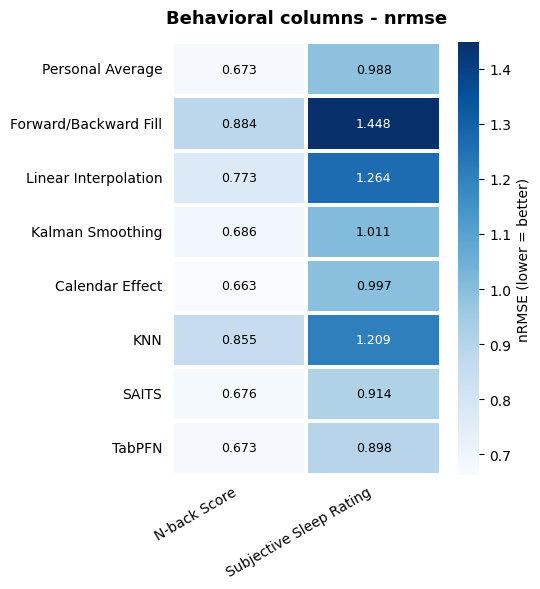

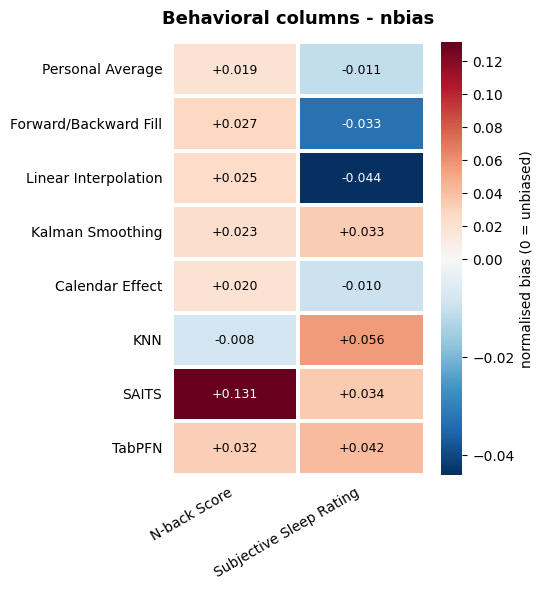

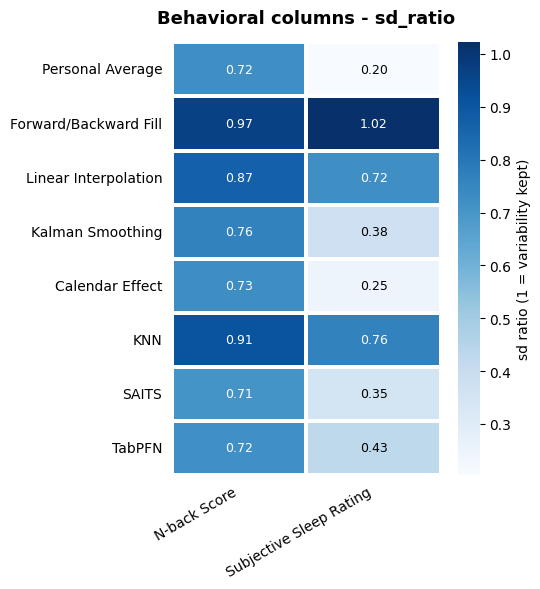

In [64]:
for metric, (cmap, center, fmt, label) in HEATMAP_SPECS.items():
    plot_metric_heatmap(
        metric_table(score_results, metric, SCORE_METHOD_ORDER).rename(columns=COLUMN_LABELS),
        title=f"Behavioral columns - {metric}",
        cmap=cmap, center=center, fmt=fmt, cbar_label=label,
        outfile=f"{FIGURE_DIR}/score_{metric}_heatmap.png",
    )

### 6.8 Exact-match accuracy for the Likert scale self-assessment

`selfassessment_value` only takes 5 values (-2,-1,0,1,2). Because the nRMSE is a prediction error, on a discrete type of data, the results can be pretty bad rapidly. So we ask a different question, what percentage of the evaluated predictions are an `exact_match` ?

In [65]:
LIKERT_LEVELS = np.array([-2, -1, 0, 1, 2])

def round_to_levels(arr, levels=LIKERT_LEVELS):
    arr = np.asarray(arr, dtype=float)
    idx = np.abs(arr[:, None] - levels[None, :]).argmin(axis=1)
    return levels[idx]


def evaluate_categorical(true_vals, imputed_df, mask_indicator, col, levels=LIKERT_LEVELS):
    idx = mask_indicator.index[mask_indicator[col]]
    y_true = true_vals.loc[idx, col].astype(float)
    y_pred = imputed_df.loc[idx, col].astype(float)
    valid = y_true.notna() & y_pred.notna()
    y_true, y_pred = y_true[valid].to_numpy(), y_pred[valid].to_numpy()
    if len(y_true) == 0:
        return {"n_eval": 0, "exact_match": np.nan}
    y_round = round_to_levels(y_pred, levels)
    return {
        "n_eval": len(y_true),
        "exact_match": float(np.mean(y_round == y_true)),
    }

_col = "selfassessment_value"
_pool = build_gap_pool(full_scores, full_scores[_col].notna() & sleep_complete, (1, 1))

cat_rows = []
for rep in range(N_REPEATS):
    for k, fold in enumerate(make_folds(_pool, N_FOLDS, seed=SEED + rep)):
        idx = [i for block in fold for i in block]
        masked, true_vals, mask_ind = mask_indices(full_scores, [_col], idx)
        for name, fn in score_methods[_col].items():
            res = evaluate_categorical(true_vals, fn(masked, cols=[_col]), mask_ind, _col)
            res["method"], res["repeat"], res["fold"] = name, rep, k
            cat_rows.append(res)
cat_results = pd.DataFrame(cat_rows)

cat_summary = cat_results.groupby("method")[["exact_match"]].mean()
display(cat_summary.loc[[m for m in SCORE_METHOD_ORDER if m in cat_summary.index]].round(3))


,exact_match
method,
user_mean,0.340
ffill_bfill,0.353
time_interp,0.346
kalman,0.395
calendar,0.348
knn,0.349
saits,0.396
tabpfn,0.435


## 7. Export the complete, filled datasets

Writes back both source files with their gaps filled, in the original format: every original row and column untouched, plus the missing ones filled in.

Two kinds of gap get filled:
- **oura_sleep** - blank physiological values on nights that exist, plus a whole new row for each night with no record at all.
- **selfreport_nback** — days with no entry at all, plus n-back scores flagged `nback_valid == 0` ??????????????

An extra `imputed` column marks which rows were touched (`1`) and which are original (`0`). New oura rows are typed `long_sleep` on purpose, so downstream code that filters on `type` still picks them up, the `imputed` column is how you tell them apart.

In [ ]:
OURA_FILL_METHOD = "kalman"
SCORES_FILL_METHOD = "kalman"
EXPORT_DIR = Path("../downstream/data")


def _finalise(out):
    if "Unnamed: 0" in out.columns:
        existing = pd.to_numeric(out["Unnamed: 0"], errors="coerce")
        start = int(existing.max()) + 1 if existing.notna().any() else 0
        blank = out["Unnamed: 0"].isna()
        out.loc[blank, "Unnamed: 0"] = [str(start + i) for i in range(int(blank.sum()))]
    return out.sort_values(["id", "day"],
                           key=lambda s: s.astype(int) if s.name == "id" else s)


def export_filled_oura(method_name, out_dir=EXPORT_DIR, flag_col="imputed"):
    """Rewrite oura_sleep.csv with the physiological gaps filled."""
    fill_map = methods[method_name](full).set_index(["id", "day"])[PHYSIO_COLS]

    raw = pd.read_csv(OURA_PATH, dtype=str)
    day, uid = pd.to_datetime(raw["day"]), raw["id"].astype(int)
    id_str = raw.groupby(uid)["id"].first()

    tsd = pd.to_numeric(raw["total_sleep_duration"], errors="coerce")
    is_night = raw["type"].isin(["long_sleep", "sleep"])
    canon_pos = (pd.DataFrame({"uid": uid, "day": day, "tsd": tsd})[is_night]
                 .sort_values(["uid", "day", "tsd"], ascending=[True, True, False])
                 .drop_duplicates(["uid", "day"], keep="first").index)

    out = raw.copy()
    out[flag_col] = "0"

    n_cells = 0
    for pos in canon_pos:
        key = (uid.loc[pos], day.loc[pos])
        if key not in fill_map.index:
            continue
        blanks = [c for c in PHYSIO_COLS if pd.isna(out.at[pos, c])]
        for c in blanks:
            out.at[pos, c] = str(fill_map.at[key, c])
        if blanks:
            n_cells += len(blanks)
            out.at[pos, flag_col] = "1"

    have = set(zip(uid.loc[canon_pos], day.loc[canon_pos]))
    new_rows = []
    for u, d in fill_map.index:
        if (u, d) in have:
            continue
        row = {c: np.nan for c in raw.columns}
        row["id"] = id_str[u]
        row["day"] = d.strftime("%Y-%m-%d")
        row["type"] = "long_sleep"
        for c in PHYSIO_COLS:
            row[c] = str(fill_map.at[(u, d), c])
        row[flag_col] = "1"
        new_rows.append(row)

    if new_rows:
        out = pd.concat([out, pd.DataFrame(new_rows)], ignore_index=True)
    out = _finalise(out)

    out_dir.mkdir(parents=True, exist_ok=True)
    path = out_dir / f"oura_sleep_imputed_{method_name}.csv"
    out.to_csv(path, index=False)
    print(f"oura   -> {path}")
    print(f"          {len(raw)} rows + {len(new_rows)} added, {n_cells} blank cells filled")
    return out

def export_filled_scores(method_name, out_dir=EXPORT_DIR, flag_col="imputed"):
    filled = full_scores.copy()
    for col in BEHAV_COLS:
        filled = score_methods[col][method_name](filled, cols=[col])
    fill_map = filled.set_index(["id", "day"])[BEHAV_COLS]

    raw = pd.read_csv(SCORES_PATH, dtype=str)
    day, uid = pd.to_datetime(raw["day"]), raw["id"].astype(int)
    id_str = raw.groupby(uid)["id"].first()

    canon_pos = (pd.DataFrame({"uid": uid, "day": day, "time": raw["time"]})
                 .sort_values(["uid", "day", "time"])
                 .drop_duplicates(["uid", "day"], keep="first").index)

    out = raw.copy()
    out[flag_col] = "0"

    n_cells = 0
    for pos in canon_pos:
        key = (uid.loc[pos], day.loc[pos])
        if key not in fill_map.index:
            continue
        touched = ["nback_score"] if str(raw.at[pos, "nback_valid"]) == "0" else []
        touched += [c for c in BEHAV_COLS if pd.isna(out.at[pos, c]) and c not in touched]
        for c in touched:
            out.at[pos, c] = str(fill_map.at[key, c])
        if touched:
            n_cells += len(touched)
            out.at[pos, flag_col] = "1"

    have = set(zip(uid.loc[canon_pos], day.loc[canon_pos]))
    new_rows = []
    for u, d in fill_map.index:
        if (u, d) in have:
            continue
        row = {c: np.nan for c in raw.columns}
        row["id"] = id_str[u]
        row["day"] = d.strftime("%Y-%m-%d")
        for c in BEHAV_COLS:
            row[c] = str(fill_map.at[(u, d), c])
        row["nback_available"] = "1"
        row["nback_valid"] = "1"
        row["selfassessment_available"] = "1"
        row[flag_col] = "1"
        new_rows.append(row)

    if new_rows:
        out = pd.concat([out, pd.DataFrame(new_rows)], ignore_index=True)
    out = _finalise(out)

    out_dir.mkdir(parents=True, exist_ok=True)
    path = out_dir / f"selfreport_nback_imputed_{method_name}.csv"
    out.to_csv(path, index=False)
    print(f"scores -> {path}")
    print(f"          {len(raw)} rows + {len(new_rows)} added, {n_cells} blank cells filled")
    return out

#export_filled_oura(OURA_FILL_METHOD)
#export_filled_scores(SCORES_FILL_METHOD)


oura   -> ..\downstream\data\oura_sleep_imputed_kalman.csv
          3222 rows + 198 added, 56 blank cells filled
scores -> ..\downstream\data\selfreport_nback_imputed_kalman.csv
          1546 rows + 375 added, 105 blank cells filled


,Unnamed: 0,id,day,time,n_correct,timings,correct_array,letters_shown,selfassessment_value,nback_score,nback_available,nback_valid,selfassessment_available,imputed
1546,1546,01,2024-06-12,NaN,NaN,NaN,NaN,NaN,-0.05391252017644227,1.758536144829767,1,1,1,1
1547,1547,01,2024-06-13,NaN,NaN,NaN,NaN,NaN,0.15796296305135044,1.74793545140137,1,1,1,1
1026,1026,01,2024-06-14,09:57:59,18,[4.24029838 0.54142812 0.39748505 0.35437818 1...,[1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. ...,[],-1,1.6728043743688636,1,1,1,0
1027,1027,01,2024-06-15,11:21:08,20,[4.25067708 0.13318578 0.34830292 0.36431292 2...,[1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. ...,[],1,1.7879140625808896,1,1,1,0
1028,1028,01,2024-06-16,06:42:00,17,[4.94153047 0.59451182 0.59515167 0.90867489 7...,[1. 1. 1. 0. 1. 1. 0. 0. 1. 1. 1. 1. 1. 1. 1. ...,[],-1,1.6921876811388867,1,1,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
395,395,29,2024-08-18,14:42:53,20,[0.71619062 4.79165635 0.48173537 3.75702755 2...,[1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. ...,['F' 'F' 'D' 'B' 'D' 'H' 'B' 'B' 'C' 'A' 'D' '...,0,1.7315843188889184,1,1,1,0
396,396,29,2024-08-19,11:03:34,19,[1.48872187 1.7309588 1.18451448 0.99527781 3...,[1. 1. 1. 1. 1. 0. 1. 1. 1. 1. 1. 1. 1. 1. 1. ...,['C' 'E' 'A' 'B' 'E' 'D' 'G' 'C' 'F' 'C' 'G' '...,1,1.5786508785894418,1,1,1,0
1920,1920,29,2024-08-20,NaN,NaN,NaN,NaN,NaN,-0.06577309243198722,1.657969728280531,1,1,1,1
397,397,29,2024-08-21,22:55:46,20,[11.36991729 1.35523896 0.59564937 1.222253...,[1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. ...,['E' 'G' 'G' 'A' 'I' 'F' 'B' 'E' 'D' 'I' 'D' '...,0,1.8969028086031003,1,1,1,0
